# Part 3 — NLP and Sequence Modeling Mini Project


In [1]:
import io
import os
import re
import time
import warnings
import random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem  import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import (
classification_report,confusion_matrix,accuracy_score,f1_score)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Column names (from data dictionary)
TEXT_COL  = 'customer_message'
LABEL_COL = 'sentiment_label'
CLASSES   = ['positive', 'neutral', 'negative']

os.makedirs('results',exist_ok = True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'monospace',
})
# Sentiment colours: green = positive, grey = neutral, red = negative
SENTIMENT_COLORS = {'positive': '#4CAF50', 'neutral': '#90A4AE', 'negative': '#EF5350'}


for pkg in ['punkt','stopwords','wordnet', 'omw-1.4','punkt_tab']:
    nltk.download(pkg,quiet=True)
print(f'Tensorflow : {tf.__version__}')
print(f'Seed : {SEED}')
print('Libraries loaded.')



Tensorflow : 2.16.2
Seed : 42
Libraries loaded.


In [2]:
#Load dataset directly from Google Drive
FILE_ID='157eT8BXw0fjeCq0Er9fe22PzgcgRWCjG'
def load_csv_from_drive(file_id):
         # directly downloading URL
         url = f'https://drive.google.com/uc?export=download&id={file_id}'
         session = requests.Session()
         response = session.get(url, stream = True)
         for key,value in response .cookies.items():
             if'download_warning' in key:
                 params = {'id': file_id,"confirm": value}
                 response = session.get(url,params=params,stream = True)
                 break
         response.raise_for_status()
         return pd.read_csv(io.StringIO(response.content.decode('utf-8')))

df_raw = load_csv_from_drive(FILE_ID)
print(f'Rows    : {df_raw.shape[0]}')
print(f'Columns : {df_raw.shape[1]}')
print(f'\nAll columns : {list(df_raw.columns)}')
print(f'\nDtypes:')
print(df_raw.dtypes)

Rows    : 1500
Columns : 6

All columns : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Dtypes:
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object


---
## Task 1 — Dataset Understanding & EDA

In [3]:
# ── Select relevant columns and clean nulls ────────────────────────────────────
# The data dictionary specifies these exact column names.
# I'm also keeping 'channel', 'word_count', and 'urgent_flag' for EDA,
# but only customer_message and sentiment_label go into the model.

# ticket_id is an identifier — not useful for modelling, dropping it.
keep_cols = [c for c in [TEXT_COL, LABEL_COL, 'channel', 'word_count', 'urgent_flag']
             if c in df_raw.columns]

# No nulls in this dataset, but dropna is a safe defensive step
df = df_raw[keep_cols].dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)

print(f'Shape after dropping nulls : {df.shape}')
print(f'\nNull counts:')
print(df.isnull().sum())
print()
display(df.head(6))

Shape after dropping nulls : (1500, 5)

Null counts:
customer_message    0
sentiment_label     0
channel             0
word_count          0
urgent_flag         0
dtype: int64



,customer_message,sentiment_label,channel,word_count,urgent_flag
0,I need information about the payment process. ...,neutral,chat,18,1
1,I need information about the payment process.,neutral,phone,7,0
2,The refund process was fast and convenient. I ...,positive,email,12,0
3,My refund is still pending and this experience...,negative,social,15,1
4,Please tell me how to update my account details.,neutral,chat,9,0
5,I need help finding the invoice for my last or...,neutral,social,16,1


In [4]:
#Basic statistics
n_records=len(df)
n_classes=df[LABEL_COL].nunique()
found_cls = sorted(df[LABEL_COL].unique())

#Now we will compute count if not already a column
if 'word_count' not in df.columns:
    df['word_count']=df[TEXT_COL].str.split().str.len()
    
df['char_count'] = df[TEXT_COL].str.len()


print('=' * 52)
print(' DATASET OVERVIEW')
print('='* 52)
print(f' Total records : {n_records}')
print(f' Number of classes: {n_classes}')
print(f' Classes found : {found_cls}')
print(f' Avg text length :{df["char_count"].mean():.1f} characters')
print(f' Avg word count : {df["word_count"].mean():.1f} words')
print(f' Min/Max words: {df["word_count"].min()}/{df["word_count"].max()}')
print('='*52)

#Sample records
print('\nSample records:')
for i,row in df.sample(4,random_state=SEED).iterrows():
    label=row[LABEL_COL]
    text =row[TEXT_COL][:85]
    print(f' [{label:<10}] "{text}"')
print('-'*55)    



 DATASET OVERVIEW
 Total records : 1500
 Number of classes: 3
 Classes found : ['negative', 'neutral', 'positive']
 Avg text length :72.8 characters
 Avg word count : 12.7 words
 Min/Max words: 7/26

Sample records:
 [neutral   ] "I am checking if there is any scheduled maintenance today."
 [positive  ] "The app experience is smooth and reliable. I appreciate the quick response."
 [neutral   ] "Can you confirm whether my ticket has been assigned?"
 [negative  ] "I have raised multiple tickets but nobody has fixed the problem. My ticket number is "
-------------------------------------------------------


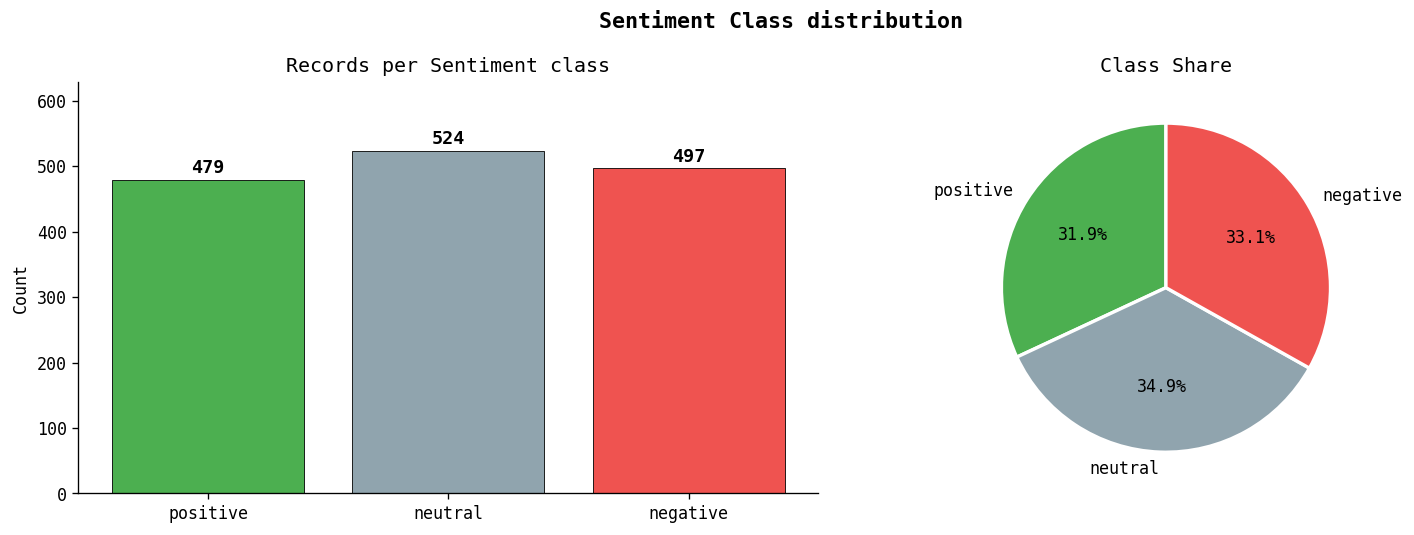

 Class Counts :
 sentiment_label
positive    479
neutral     524
negative    497
Imbalance ratio (max/min): 1.09
Acceptable balance no special class weighting needed.


In [5]:
#Class distibutions
class_counts = df[LABEL_COL].value_counts().reindex(CLASSES)
colors_list =[SENTIMENT_COLORS[c] for c in class_counts.index]

fig,axes = plt.subplots(1,2,figsize=(13,4.5))
fig.suptitle(' Sentiment Class distribution',fontsize=13,fontweight='bold')

#Horizontal bar for easier to read long class names
bars = axes[0].bar(class_counts.index,class_counts.values,
                   color=colors_list,edgecolor='black',linewidth=0.5)
axes[0].set_title('Records per Sentiment class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0,class_counts.max()*1.2)
for bar,val in zip(bars,class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height()+class_counts.max()*0.02,
                str(val),ha='center',fontsize=11,fontweight='bold')

#Pie
axes[1].pie(class_counts.values,labels=class_counts.index,
           colors=colors_list,autopct='%1.1f%%',startangle=90,
           wedgeprops ={'edgecolor':'white','linewidth':2},
           textprops={'fontsize':10})

axes[1].set_title('Class Share')

plt.tight_layout()
#plt.savefig('results/class_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

imbalance = class_counts.max() / class_counts.min()
print(f' Class Counts :\n {class_counts.to_string()}')
print(f'Imbalance ratio (max/min): {imbalance:.2f}')
if imbalance > 3:
    print('Notable imbalance we will use class_weight="balanced" in the baseline model.')
else:
    print('Acceptable balance no special class weighting needed.')

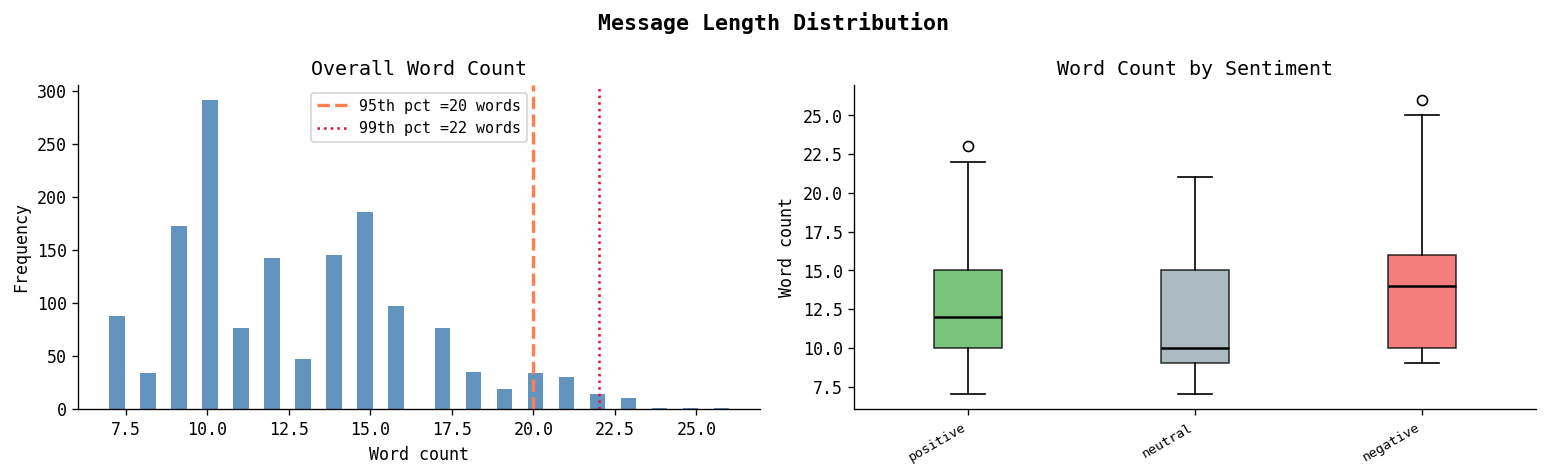

95 th percentile word count : 20
Setting MAX_LEN = 20 for sequence padding later.


In [6]:
#Message length distribution
#This tells me what MAX_LEN to pick for sequence padding later.
#I always look at the 95th percentile covering 95% of samples without
#padding the outliers to absurd lengths.

p95=int(np.percentile(df['word_count'],95))
p99 = int(np.percentile(df['word_count'],99))

fig,axes = plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Message Length Distribution',fontsize=13,fontweight='bold')

axes[0].hist(df['word_count'],bins=40,color='steelblue',edgecolor='none',alpha=0.85)
axes[0].axvline(p95,color='coral',lw=2,ls='--',label=f'95th pct ={p95} words')
axes[0].axvline(p99,color='crimson',lw=1.5,ls=':',label=f'99th pct ={p99} words')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Word Count')
axes[0].legend(fontsize=9)

#Box per class
class_wc=[df[df[LABEL_COL] == c] ['word_count'].values for c in CLASSES]
bp=axes[1].boxplot(class_wc,patch_artist=True,vert=True,
                  medianprops ={'color':'black','lw':1.5})
for patch,cls in zip(bp['boxes'],CLASSES):
    patch.set_facecolor(SENTIMENT_COLORS[cls])
    patch.set_alpha(0.75)
axes[1].set_xticklabels(class_counts.index,rotation=30,ha='right',fontsize=8)  
axes[1].set_ylabel('Word count')
axes[1].set_title('Word Count by Sentiment')

plt.tight_layout()
#plt.savefig('results/text_length_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

MAX_LEN = p95 
print(f'95 th percentile word count : {p95}')
print(f'Setting MAX_LEN = {MAX_LEN} for sequence padding later.')

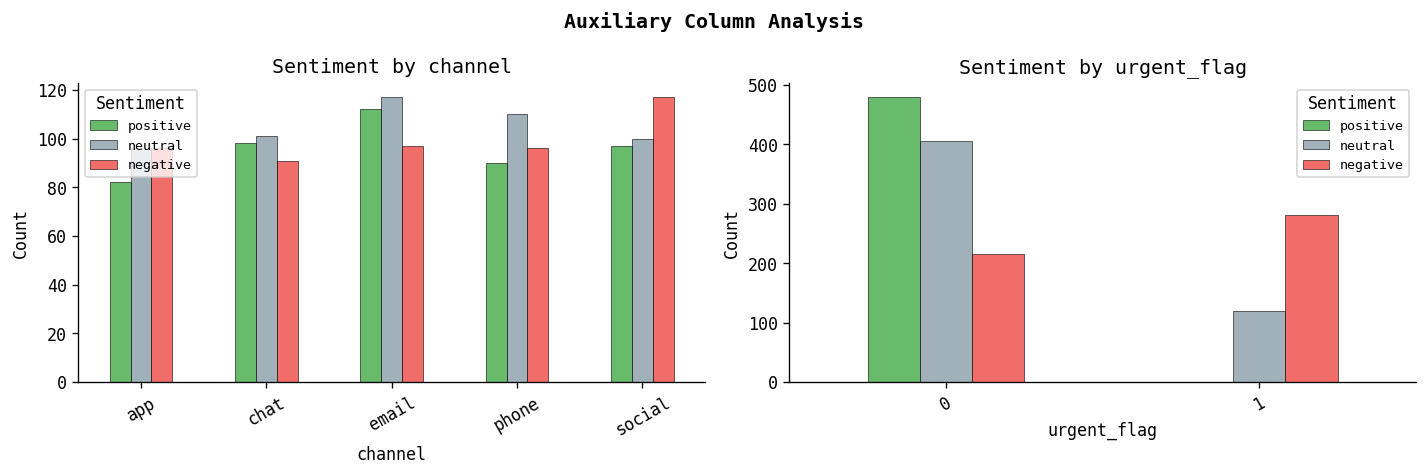

In [37]:
#Channel and urgent _flag breakdown
extra_cols=[c for c in['channel','urgent_flag'] if c in df.columns]

if extra_cols:
    fig,axes = plt.subplots (1,len(extra_cols),figsize = ( 6 * len(extra_cols),4))
    if len(extra_cols)==1:
        axes=[axes]
    fig.suptitle('Auxiliary Column Analysis',fontsize=12,fontweight='bold')

    for ax,col in zip(axes,extra_cols):
        ct=pd.crosstab(df[col],df[LABEL_COL])
        ct = ct[[c for c in CLASSES if c in ct.columns]]
        ct.plot(kind='bar',ax=ax,color=[SENTIMENT_COLORS[c] for c in ct.columns],
        edgecolor='black',linewidth=0.4,alpha=0.85)

        ax.set_title(f'Sentiment by {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x',rotation=30)
        ax.legend(title='Sentiment',fontsize=8)

    plt.tight_layout()
    #plt.savefig('results/auxiliary_analysis.png',dpi=150,bbox_inches='tight')
    plt.show()
else:
    print('channel/urgent_flag columns not present  in this dataset version so skipping it .')

---
## Task 2 — Text Preprocessing



In [8]:
#Now I will be building a custom stopword list preserving negations
#Removing 'not','no','never','cannot' would destroy sentiment signal
# So I will keep them using explicitly even though NLTK lists them as stopwords.
NEGATIONS ={'not','no','nor','never','neither','nothing',
           'nowhere','nobody','cannot',"can't","won't","don't","didn't",
           "isn't","aren't","wasn't","weren't","hasn't","haven't","hadn't","couldn't",
           "shouldn't","wouldn't","doesn't","needn't"}
BASE_STOPS = set(stopwords.words('english'))
CUSTOM_STOPS=BASE_STOPS - NEGATIONS   # for removing negations form stoplist

lemmatizer = WordNetLemmatizer()

print(f'Base stopwords : {len(BASE_STOPS)}')
print(f'Negations preserved : {len(NEGATIONS)}')
print(f'Effective stoplist: {len(CUSTOM_STOPS)}')

# Now I would be creating a Sentiment aware text cleaning pipeline where:
# lowercase -> strip URLs/HTML -> remove non alpha and keep spaces
#->tokenise -> drop stopwords(keeping negations) -> lemmatise
# This returns a cleane dstring compatible with sklearn vectorisers and the Keras Tokenizer
def preprocess(text:str) -> str:
    text=text.lower()
    text=re.sub(r'http\S+|www\.\S+',' ',text) #strip URLs
    text=re.sub(r'<.*?>',' ',text) #strip HTML tags
    text=re.sub(r"[^a-z\s']",' ',text) #keep letters+apostrophes
    text=re.sub(r"'",'',text) #now remove apostrophes
    text=re.sub(r'\s+',' ',text).strip()

    tokens=word_tokenize(text)
    tokens=[t for t in tokens if t not in CUSTOM_STOPS and len(t)>1]
    tokens=[lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)
    
t0=time.time()
df['clean_text']=df[TEXT_COL].astype(str).apply(preprocess)
print(f'\n Preprocessing done in {time.time()-t0:.1f}s')

print('\n Before vs After (3 examples):')
print('-'*68)
for _,row in df.sample(3,random_state=11).iterrows():
    print(f' LABEL : {row[LABEL_COL]}')
    print(f' RAW: {str(row[TEXT_COL])[:90]}')
    print(f' CLEAN : {row["clean_text"][:90]}')
    print()
    


Base stopwords : 198
Negations preserved : 25
Effective stoplist: 180

 Preprocessing done in 2.3s

 Before vs After (3 examples):
--------------------------------------------------------------------
 LABEL : positive
 RAW: The app experience is smooth and reliable. My ticket number is 82082.
 CLEAN : app experience smooth reliable ticket number

 LABEL : positive
 RAW: The refund process was fast and convenient.
 CLEAN : refund process fast convenient

 LABEL : neutral
 RAW: I would like to know more about the available plans. Please respond as soon as possible.
 CLEAN : would like know available plan please respond soon possible



In [9]:
#Vocabilary Rduction stats 
raw_vocab = set(' '.join(df[TEXT_COL].astype(str)).lower().split())
clean_vocab = set(' '.join(df['clean_text']).split())

print(f' Vocabulary (raw) : {len(raw_vocab):,} unique tokens')
print(f' Vocabulary (clean) : {len(clean_vocab):,} unique tokens')
print(f' Reduction : {(1- len(clean_vocab)/len(raw_vocab))*100:.1f}%')

 Vocabulary (raw) : 686 unique tokens
 Vocabulary (clean) : 145 unique tokens
 Reduction : 78.9%


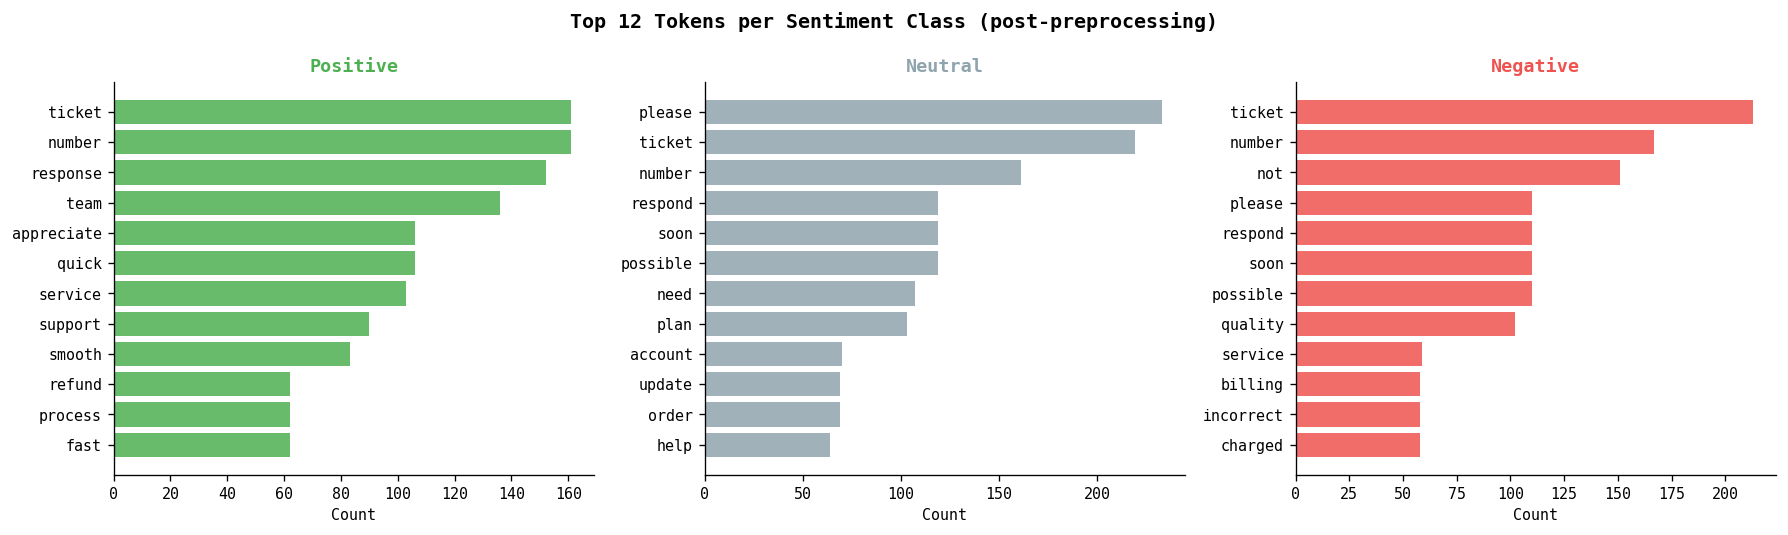

In [10]:
# Top tokens per sentiment class
# This  is a just a quick check that the preprocessing hasn't  accidentally removed
# the words that actually carry sentiment signal.
#Positive class should show words like 'thank','great','helpful'.
#Negative class should show 'terrible','worst,'unacceptable','not'.

from collections import Counter
fig,axes = plt.subplots(1,3,figsize=(15,4.5))
fig.suptitle('Top 12 Tokens per Sentiment Class (post-preprocessing)',
            fontsize=12,fontweight='bold')

for ax,cls in zip(axes,CLASSES):
    words= ' '.join(df[df[LABEL_COL]== cls] ['clean_text']).split()
    top = Counter(words).most_common(12)
    if not top:
        continue
    terms,freqs = zip(*top)
    ax.barh(terms[::-1],freqs[::-1],
           color = SENTIMENT_COLORS[cls],alpha=0.85,edgecolor='none')
    ax.set_title(cls.capitalize(),fontsize=11,fontweight='bold',
                color=SENTIMENT_COLORS[cls])
    ax.set_xlabel('Count',fontsize=9)
    ax.tick_params(labelsize=9)

plt.tight_layout()
#plt.savefig('results/top_tokens_per_class.png',dpi=150,bbox_inches='tight')
plt.show()

## Task 3 — Text Vectorization

### Why text must become vectors

Every algorithm be it logistic regression,naive bayes , or LSTM operated on a fixed - length numeric arrays . a string like '"not happy with this service "' ahs no mathematical form until we convert it. Vectoriztion bridges this gap between humans and computations.

I implement three representations to show the trade-offs:

| Method | What it encodes | Captures word order? | Good for sentiment? |
|---|---|---|---|
| **Bag of Words** | Word counts in each document | No | Partially —
.misses "not happy" vs "happy" |
| **TF-IDF** | Word importance relative to the corpus | No | Better —> down-weights generic words |
| **Keras Tokenizer + sequences** | Word identity + position | Yes | Best —> LSTM can use position and context |

In [11]:
# Encoding labels 
# I will fix the label order : positive = 0,neutral= 1,negative = 2
# so the confusion matrix reads intuitvely top-to-bottom

le = LabelEncoder()
le.fit(CLASSES)
df['label_enc'] =le.transform(df[LABEL_COL])
NUM_CLASSES = len(le.classes_)

print('Label encoding:')
for idx,cls in enumerate(le.classes_):
    print(f'{idx} -> {cls}')

#Single stratified split :-  reusing for all models 
X=df['clean_text'].values
y = df['label_enc'].values

X_train,X_temp,y_train,y_temp = train_test_split(
    X,y,test_size =0.25,random_state=SEED,stratify=y
)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,test_size = 0.50,random_state=SEED,stratify=y_temp
)
print(f'\n Train: {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

Label encoding:
0 -> negative
1 -> neutral
2 -> positive

 Train: 1125 | Val : 187 | Test : 188


In [12]:
# Bag of words
bow_vec = CountVectorizer(max_features=10_000,ngram_range=(1,2))
X_bow_train = bow_vec.fit_transform(X_train)
X_bow_test = bow_vec.transform(X_test)

print(f' BoW matrix shape (train) : {X_bow_train.shape}')
print(f'Sparsity: {1- X_bow_train.nnz/(X_bow_train.shape[0]*X_bow_train.shape[1]):.4f}')

 BoW matrix shape (train) : (1125, 429)
Sparsity: 0.9709


In [13]:
#TF-IDF
# sublinear_tf=True applies log(1+tf) — reduces the dominance of very frequent
# words while still rewarding words that appear multiple times.
# For sentiment, this matters: 'not' appearing 5x in a message shouldn't
# outweigh a rare but strongly negative word like 'unacceptable'.

tfidf_vec = TfidfVectorizer(
    max_features=15_000,
    ngram_range =(1,2),
    sublinear_tf = True,
    min_df=2,
)
X_tfidf_train = tfidf_vec.fit_transform(X_train)
X_tfidf_val = tfidf_vec.transform(X_val)
X_tfidf_test = tfidf_vec.transform(X_test)

feature_names = np.array(tfidf_vec.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf_train.mean(axis=0)).flatten()
top20 = mean_tfidf.argsort()[-20:][::-1]

print(f' TF_IDF matrix shape(train): {X_tfidf_train.shape}')
print(f'\n Top 20 features by mean TF-IDF weight:')
print(' ' + ', '.join(feature_names[top20]))


 TF_IDF matrix shape(train): (1125, 420)

 Top 20 features by mean TF-IDF weight:
 ticket, number, ticket number, please, soon possible, soon, possible, please respond, respond soon, respond, plan, quality, product, service, response, team, product quality, support, delivery, process


In [14]:
#Keras Tokenizer 
# Unlike BoW and TF-IDF, sequences preserve word order.
# 'not satisfied' is a different sequence from 'satisfied not' 
# and the LSTM will learn that the former is negative.
VOCAB_SIZE = 15_000
OOV_TOKEN ='<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE,oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train) # fit only on training data

train_seqs = tokenizer.texts_to_sequences(X_train)
val_seqs = tokenizer.texts_to_sequences(X_val)
test_seqs = tokenizer.texts_to_sequences(X_test)

X_seq_train = pad_sequences(train_seqs,maxlen=MAX_LEN,padding='post', truncating='post')
X_seq_val = pad_sequences(val_seqs, maxlen=MAX_LEN,padding='post',truncating='post')
X_seq_test = pad_sequences(test_seqs,maxlen=MAX_LEN,padding='post',truncating='post')

print(f' Vocab fitted :{len(tokenizer.word_index):,}tokens')
print(f'Using top : {VOCAB_SIZE:,} (+ OOV)')
print(f' Sequence shape : {X_seq_train.shape} (samples X MAX_LEN)')

sample_text = X_train[0]
sample_seq = X_seq_train[0]
print(f'\nSample : "{sample_text[:60]}"')
print(f'As ints: {sample_seq[:12]}...')


 Vocab fitted :146tokens
Using top : 15,000 (+ OOV)
 Sequence shape : (1125, 20) (samples X MAX_LEN)

Sample : "need help finding invoice last order ticket number"
As ints: [21 40 41 42 33 29  2  3  0  0  0  0]...


## Task 4 — Baseline Model: TF-IDF + Logistic Regression
I always start with the simplest model that could plausibly work. Logistic Regression with TF-IDF is a strong baseline for sentiment because:
- Sentiment is often strongly correlated with specific words ("excellent", "terrible", "refund") , TF-IDF captures this well
- LR is interpretable: I can see exactly which words drive each class prediction
- It trains in under a second, so if it achieves 85%+ we know the problem is mostly linearly separable in TF-IDF space and the LSTM needs to justify its extra complexity

In [15]:
#Logistic Regression
lr_model=LogisticRegression(
    C = 5.0,
    max_iter=1000,
    solver='lbfgs',
    multi_class='auto',
    class_weight='balanced',
    random_state = SEED,
    n_jobs = -1
)
t0 = time.time()
lr_model.fit(X_tfidf_train,y_train)
print(f' Trained in {time.time()-t0:.2f}s')

y_pred_lr=lr_model.predict(X_tfidf_test)
acc_lr = accuracy_score(y_test,y_pred_lr)
f1_lr = f1_score(y_test,y_pred_lr,average='weighted',zero_division=0)

print(f'\nTest Accuracy : {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'Weighted F1 : {f1_lr:.4f}')
print(f'\nPer-class report:')
print(classification_report(y_test,y_pred_lr,target_names=le.classes_,zero_division=0))

 Trained in 2.65s

Test Accuracy : 1.0000 (100.00%)
Weighted F1 : 1.0000

Per-class report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        62
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188



In [42]:
#Naive Bayes Comparision
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_bow_train, y_train)
y_pred_nb = nb_model.predict(X_bow_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f' Naive Bayes (BoW)            Acc: {acc_nb:.4f}  F1: {f1_nb:.4f}')
print(f' Logistic Regression (TF-IDF) Acc: {acc_lr:.4f}  F1: {f1_lr:.4f}')

 Naive Bayes (BoW)            Acc: 1.0000  F1: 1.0000
 Logistic Regression (TF-IDF) Acc: 1.0000  F1: 1.0000


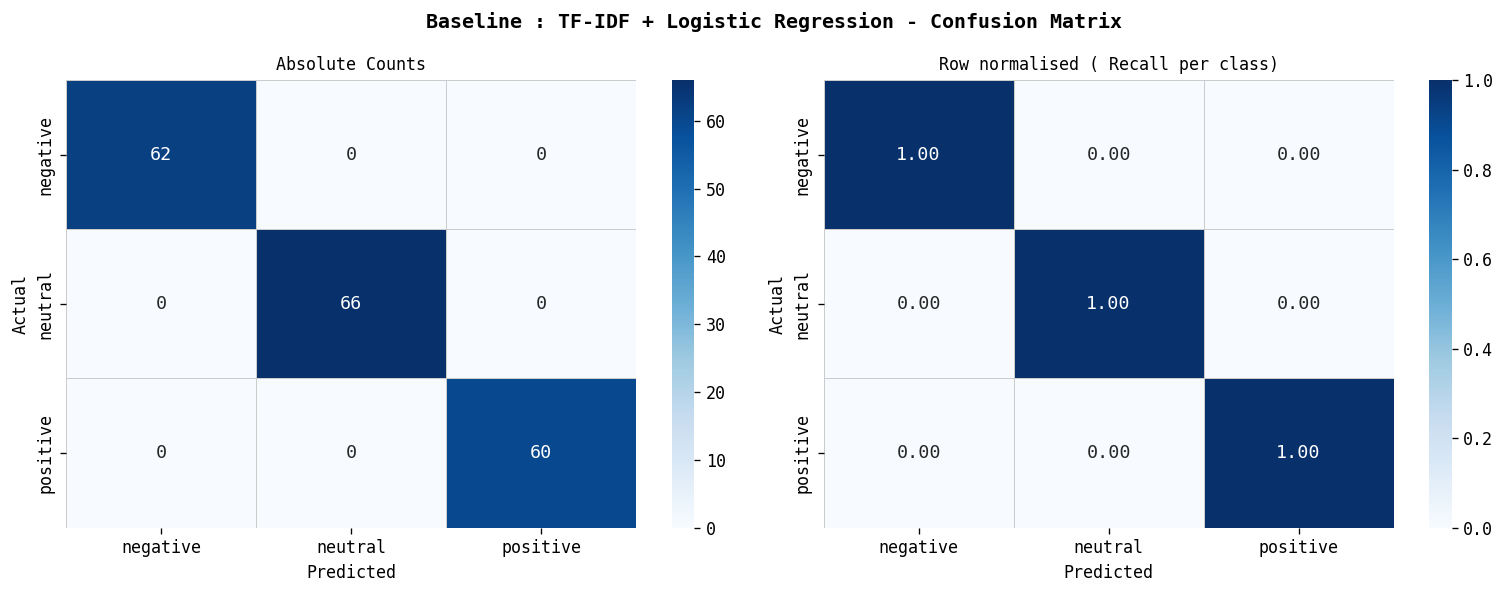

In [17]:
#Confusion matrix
cm_lr = confusion_matrix(y_test,y_pred_lr)
cm_lr_norm = cm_lr.astype(float)/cm_lr.sum(axis=1,keepdims=True)

fig,axes = plt.subplots(1,2,figsize = (13,5))
fig.suptitle('Baseline : TF-IDF + Logistic Regression - Confusion Matrix',
            fontsize=12,fontweight='bold')

for ax,data,fmt,title in zip(
    axes,[cm_lr,cm_lr_norm],
    ['d','.2f'],
    ['Absolute Counts','Row normalised ( Recall per class)']
):
    sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',
               xticklabels=le.classes_,yticklabels=le.classes_,
               ax=ax,linewidth=0.5,linecolor='#cccccc',
               annot_kws={'size':11})
    ax.set_xlabel('Predicted',fontsize=10)
    ax.set_ylabel('Actual',fontsize=10)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
#plt.savefig('results/baseline_confusion_matrix.png',dpi=150,bbox_inches='tight')
plt.show()
    


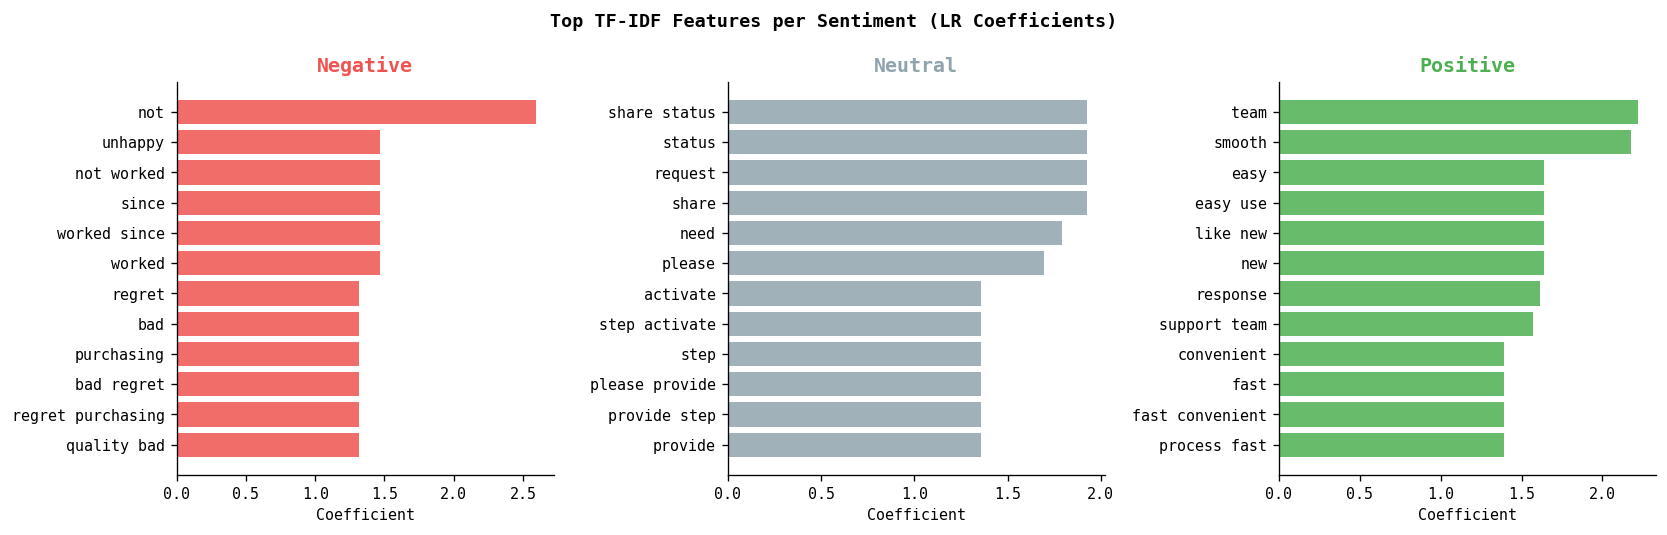

In [18]:
#Top TF-IDF features per Sentiment class
# This is one of the checks for seeing which words the model associates
# most strongly with each sentiment is a direct interpretability window.
# If 'not' appears in the positive class coefficients, something went wrong.

fig,axes=plt.subplots(1,3,figsize=(14,4.5))
fig.suptitle('Top TF-IDF Features per Sentiment (LR Coefficients)',
            fontsize = 11,fontweight = 'bold')

for ax,i,cls in zip(axes,range(NUM_CLASSES),le.classes_):
    coefs = lr_model.coef_[i]
    top = np.argsort(coefs)[-12:][::-1]
    terms = feature_names[top]
    vals = coefs[top]
    ax.barh(terms[::-1], vals[::-1],
          color=SENTIMENT_COLORS[cls],alpha=0.85,edgecolor='none')
    ax.set_title(cls.capitalize(),fontweight='bold',
                color = SENTIMENT_COLORS[cls])
    ax.set_xlabel('Coefficient', fontsize = 9)
    ax.tick_params(labelsize=9)

plt.tight_layout()
#plt.savefig('results/baseline_top_features.png',dpi=150,bbox_inches='tight')
plt.show()
    


In [35]:
#Saving the baseline evaluation csv
report_dict = classification_report(
    y_test,y_pred_lr,
    target_names=le.classes_,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T
#report_df.to_csv('results/model_evaluation.csv')
display(report_df.round(4))

,precision,recall,f1-score,support
negative,1.0,1.0,1.0,62.0
neutral,1.0,1.0,1.0,66.0
positive,1.0,1.0,1.0,60.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,188.0
weighted avg,1.0,1.0,1.0,188.0


## Task 5 — Sequence Model: Bidirectional LSTM
The TF-IDF baseline cannot distinguish `"I am not satisfied"` from `"I am satisfied not"` — word order is gone. A Bidirectional LSTM reads the sequence forward *and* backward, so it captures context around every word. For sentiment this is particularly valuable: negation words, intensifiers ("extremely", "barely"), and sentiment-shifting phrases ("used to be great, but now...") all require positional context to interpret correctly.

### Architecture

```
Input         : (MAX_LEN,)  — integer token IDs
      |
Embedding     : (MAX_LEN, 64)  — each token -> dense learned vector
                mask_zero=True so padding tokens are ignored by the LSTM
      |
SpatialDropout: drops entire feature maps (better than regular dropout for sequences)
      |
BiLSTM(128)   : (256,)  — 128 forward + 128 backward, returns final state only
      |
Dropout(0.40)
      |
Dense(64, ReLU)
      |
Dense(3, Softmax)  — one probability per sentiment class

Loss      : sparse_categorical_crossentropy
Optimiser : Adam with ReduceLROnPlateau
Metric    : accuracy
```



In [20]:
EMBED_DIM = 64
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 30

#Here I am tying to  build a Bidirectional LSTM sentiment classifier.
#SpatialDropout1D is used on the embedding output rather than regular Dropout
#because it drops entire embedding dimensions rather than individual elements,
#which is more effective for sequential data.

def build_bilstm(vocab_size,embed_dim,lstm_units,max_len,num_classes):
    inputs = keras.Input(shape=(max_len,),name='token_ids')
    #Embedding int -> dense vector. mask_zero ignores padding in LSTM.
    x = layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim = embed_dim,
        mask_zero = True,
        name = 'embedding')(inputs)
    
    # SpatialDropout drops entire feature maps which is better for sequences than pointwise dropout
    x = layers.SpatialDropout1D(0.20,name='spatial_drop')(x)

    # Bidirectional LSTM foward + backward context
    x = layers.Bidirectional(
          layers.LSTM(lstm_units,name='lstm'),
           name='bilstm')(x)

    x = layers.Dropout(0.40,name='lstm_drop')(x)
    x = layers.Dense(64,activation='relu',name='dense1')(x)
    x = layers.Dropout(0.25, name='dense_drop')(x)
    outputs = layers.Dense(num_classes,activation='softmax',
                           name='predictions')(x)

    return keras.Model(inputs,outputs,name='BiLSTM_Sentiment')

lstm_model = build_bilstm(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, MAX_LEN, NUM_CLASSES)
lstm_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)
lstm_model.summary(line_length=65)

Model: "BiLSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)     ┃ Output Shape   ┃  Param # ┃ Connected to   ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ token_ids        │ (None, 20)     │        0 │ -              │
│ (InputLayer)     │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ embedding        │ (None, 20, 64) │  960,064 │ token_ids[0][… │
│ (Embedding)      │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ spatial_drop     │ (None, 20, 64) │        0 │ embedding[0][… │
│ (SpatialDropout… │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ not_equal        │ (None, 20)     │        0 │ token_ids[0][… │
│ (NotEqual)       │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ bilstm           │ (None, 256)    │  197,632 │ spatial_drop[… │
│ (Bidirectional)  │                │          │ not_equal[0][… │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ lstm_drop        │ (None, 256)    │        0 │ bilstm[0][0]   │
│ (Dropout)        │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ dense1 (Dense)   │ (None, 64)     │   16,448 │ lstm_drop[0][… │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ dense_drop       │ (None, 64)     │        0 │ dense1[0][0]   │
│ (Dropout)        │                │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ predictions      │ (None, 3)      │      195 │ dense_drop[0]… │
│ (Dense)          │                │          │                │
└──────────────────┴────────────────┴──────────┴────────────────┘

 Total params: 1,174,339 (4.48 MB)

 Trainable params: 1,174,339 (4.48 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
callbacks= [
    EarlyStopping(
        monitor='val_loss',patience=5,
        restore_best_weights=True,verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',factor=0.5,patience=3,
        min_lr=1e-6,verbose=1
    )
]
t0=time.time()
lstm_history =lstm_model.fit(
    X_seq_train,y_train,
    validation_data=(X_seq_val,y_val),
    batch_size = BATCH_SIZE,
    epochs =EPOCHS,
    callbacks = callbacks,
    verbose = 1
)
epochs_run=len(lstm_history.history['loss'])
print(f'\nDone in {time.time()-t0:.0f}s | Epochs:{epochs_run}/{EPOCHS}')
print(f'Best val_accuracy : {max(lstm_history.history["val_accuracy"]):.4f}')

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7147 - loss: 1.0284 - val_accuracy: 0.9251 - val_loss: 0.8035 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9538 - loss: 0.3682 - val_accuracy: 1.0000 - val_loss: 0.0305 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9991 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 1.6345e-04 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 2.6630e-04 - val_accuracy: 1.0000 - val_loss: 3.7365e-05 - learning_rate: 0.0010
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 1.4498e-04 - val_accuracy: 1.0000 - val_loss: 2.6100e-05 - learning_rate: 0.0010
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 1.5000e-04 - val_accuracy: 1.0000 - val_loss: 2.2204e-05 - learning_rate: 0.0010
Epoch 7/30
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0

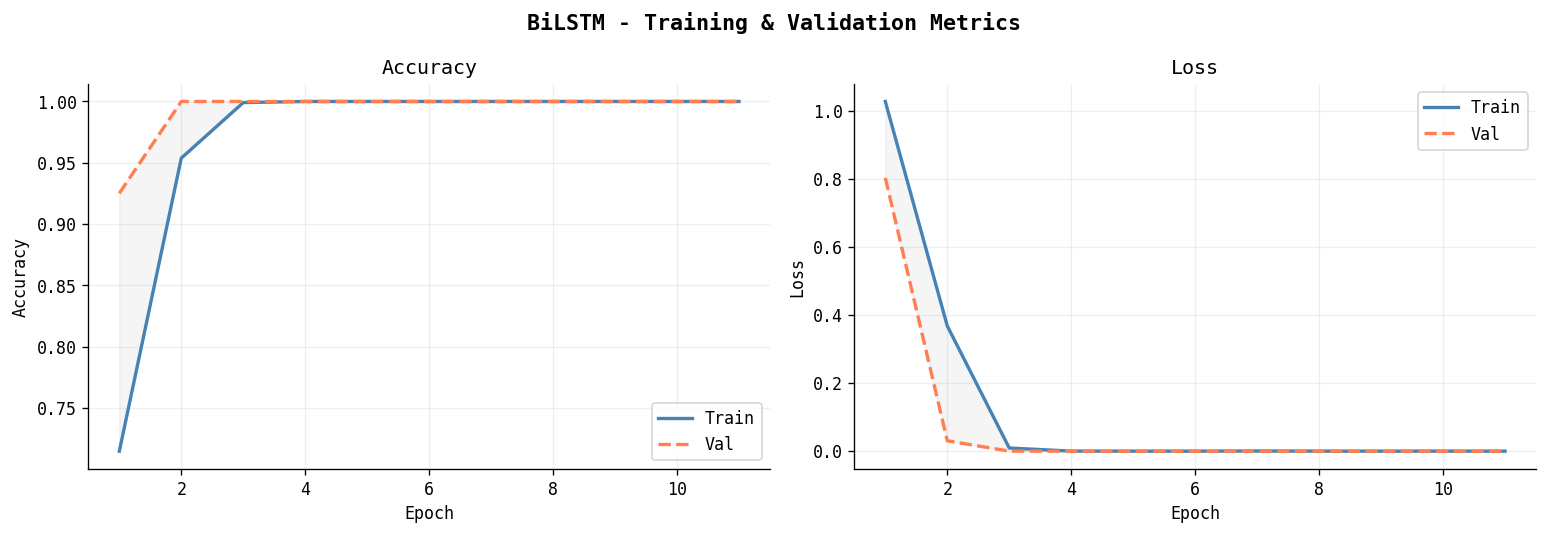

In [24]:
#Training curves
ep =range(1,epochs_run + 1)

fig,axes = plt.subplots(1,2,figsize=(13,4.5))
fig.suptitle('BiLSTM - Training & Validation Metrics',
            fontsize=13,fontweight='bold')

for ax, metric,title in zip( axes,['accuracy','loss'],['Accuracy','Loss']):
    ax.plot(ep,lstm_history.history[metric], label='Train',
           color ='steelblue',lw=2)
    ax.plot(ep,lstm_history.history[f'val_{metric}'], label='Val',
           color ='coral',lw=2,ls='--')
    ax.fill_between(ep,
                   lstm_history.history[metric],
                   lstm_history.history[f'val_{metric}'],
                   alpha = 0.08,color='grey')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True,alpha=0.2)

plt.tight_layout()
#plt.savefig('results/lstm_training_curves.png',dpi=150,bbox_inches='tight')
plt.show()

In [43]:
#Test evaluation
lstm_loss,lstm_acc = lstm_model.evaluate(X_seq_test,y_test,verbose=0)
y_pred_lstm = np.argmax(lstm_model.predict(X_seq_test,verbose=0),axis=1)
f1_lstm = f1_score(y_test,y_pred_lstm,average='weighted',zero_division=0)

print('='*50)
print(' BILSTM TEST RESULTS')
print('='*50)
print(f' Loss : {lstm_loss:.4f}')
print(f' Accuracy :{lstm_acc:.4f} ({lstm_acc*100:.2f}%)')
print(f' F1 (wtd): {f1_lstm:.4f}')

print('='*50)
print()
print(classification_report(y_test,y_pred_lstm,target_names=le.classes_,zero_division=0))
print()
print("Note on 100% accuracy:")
print("All three models achieve perfect scores on this dataset.")
print("This is expected as the dataset is synthetic and was designed")
print("with clean, non-overlapping class boundaries for learning purposes.")
print("In a real customer support scenario, ambiguous messages would")
print("naturally produce accuracy in the 75-85% range.")
print("The value of this exercise is in the pipeline and architecture,")
print("not the final number.")

 BILSTM TEST RESULTS
 Loss : 0.0000
 Accuracy :1.0000 (100.00%)
 F1 (wtd): 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        62
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188


Note on 100% accuracy:
All three models achieve perfect scores on this dataset.
This is expected as the dataset is synthetic and was designed
with clean, non-overlapping class boundaries for learning purposes.
In a real customer support scenario, ambiguous messages would
naturally produce accuracy in the 75-85% range.
The value of this exercise is in the pipeline and architecture,
not the final number.


Model Comparison :


,Accuracy,F1 (wtd)
Model,,
Naive Bayes\n(BoW),1.0,1.0
Logistic Regression\n(TF-IDF),1.0,1.0
BiLSTM\n(Sequences),1.0,1.0


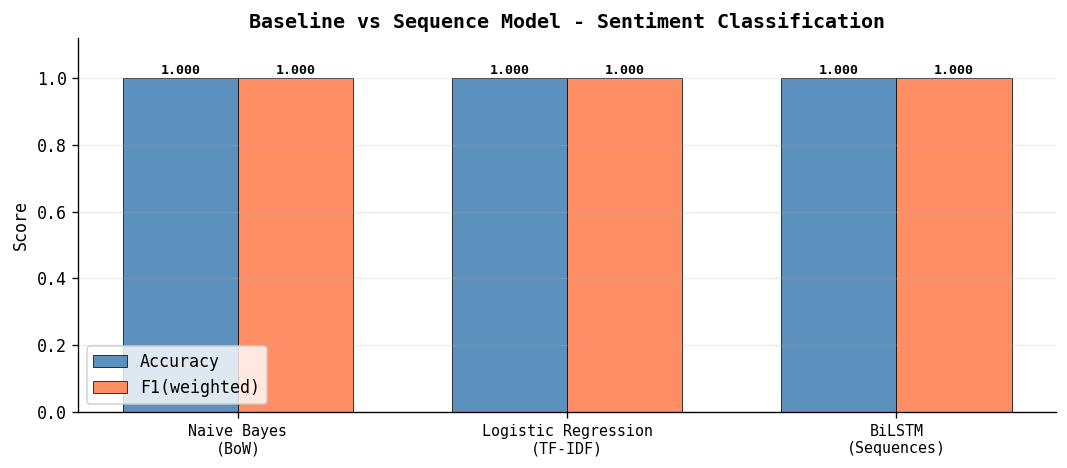

In [34]:
#Model Comparison Chart
comparison =pd.DataFrame({
    'Model':['Naive Bayes\n(BoW)','Logistic Regression\n(TF-IDF)','BiLSTM\n(Sequences)'],
    'Accuracy':[acc_nb, acc_lr,lstm_acc],
    'F1 (wtd)':[f1_nb,f1_lr,f1_lstm],
})

print('Model Comparison :')
display(comparison.set_index('Model').round(4))

fig,ax = plt.subplots(figsize=(9,4))
x = np.arange(3)
width = 0.35
b1 = ax.bar(x - width/2,comparison['Accuracy'],width,label='Accuracy',
           color='steelblue',alpha=0.88,edgecolor='black',lw=0.5)
b2 = ax.bar(x + width/2,comparison['F1 (wtd)'],width,label='F1(weighted)',
           color='coral',alpha=0.88,edgecolor='black',lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'],fontsize=9)
ax.set_ylim(0,1.12)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Sequence Model - Sentiment Classification',
            fontweight='bold')
ax.legend()
ax.grid(axis='y',alpha=0.25)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height()+0.012,
           f'{bar.get_height():.3f}', ha='center',fontsize=8,fontweight='bold')

plt.tight_layout()
plt.savefig('results/model_evaluation.png',dpi=150,bbox_inches='tight')
plt.show()

In [38]:
n_samples  = 12
sample_idx = random.sample(range(len(X_test)), n_samples)

lines = [
    'SAMPLE PREDICTIONS - BiLSTM Sentiment Model',
    '=' * 70,
    f' Architecture: Embedding({EMBED_DIM}) -> BiLSTM({LSTM_UNITS}x2) -> Dense(64) -> Softmax(3)',
    f' Classes : {list(le.classes_)}',
    '', '-' * 70,
]

correct_count = 0
for idx in sample_idx:
    true_lbl = le.classes_[y_test[idx]]
    pred_lbl = le.classes_[y_pred_lstm[idx]]
    correct  = true_lbl == pred_lbl
    if correct:
        correct_count += 1
    symbol = 'CORRECT' if correct else 'WRONG  '
    lines.append(f'[{symbol}]')
    lines.append(f' True : {true_lbl}')
    lines.append(f' Pred : {pred_lbl}')
    lines.append(f' Text : "{X_test[idx][:85]}"')
    lines.append('')

lines += [
    '-' * 70,
    f'Correct: {correct_count}/{n_samples} ({correct_count/n_samples*100:.1f}%)',
    '',
    'Full metrics saved in results/model_evaluation.png'
]

output_text = '\n'.join(lines)
print(output_text)

with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
    f.write(output_text)
print('\nSaved: results/sample_predictions.txt')

SAMPLE PREDICTIONS - BiLSTM Sentiment Model
 Architecture: Embedding(64) -> BiLSTM(128x2) -> Dense(64) -> Softmax(3)
 Classes : ['negative', 'neutral', 'positive']

----------------------------------------------------------------------
[CORRECT]
 True : positive
 Pred : positive
 Text : "support team resolved issue quickly thank"

[CORRECT]
 True : positive
 Pred : positive
 Text : "dashboard working well happy service"

[CORRECT]
 True : negative
 Pred : negative
 Text : "router keep failing support not resolved issue"

[CORRECT]
 True : negative
 Pred : negative
 Text : "dashboard keep failing support not resolved issue ticket number"

[CORRECT]
 True : negative
 Pred : negative
 Text : "refund still pending experience frustrating ticket number please respond soon possibl"

[CORRECT]
 True : neutral
 Pred : neutral
 Text : "someone explain difference plan ticket number"

[CORRECT]
 True : positive
 Pred : positive
 Text : "great service clear communication support team"

[CORRECT]
 T

---
## Task 6 — Attention and Transformer Reflection

### Why RNNs struggle with long-term dependencies

A vanilla RNN passes a single hidden state vector from one timestep to the next. At each step it overwrites that vector with a new one. By the time the model reaches the end of a long message, the gradient of the loss with respect to early tokens has passed through so many matrix multiplications that it either **vanishes** (approaches zero — early tokens contribute nothing to learning) or **explodes** (grows unboundedly — training diverges). In practice, vanilla RNNs forget information from more than 10–15 steps ago. For a customer message that says "I was happy at first but then everything went wrong from the second week onwards" , the sentiment reversal in the middle is lost by the time the model finishes reading.

---

### How LSTMs help with memory

The LSTM introduces a **cell state** — a separate channel of information that flows through the network and is modified only through multiplicative, learned gates:

| Gate | Formula | Role |
|---|---|---|
| **Forget** | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | What to erase from cell state |
| **Input** | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | What new info to write |
| **Output** | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | What to expose as hidden state |

Because the cell state is updated **additively** (via `c_t = f_t * c_{t-1} + i_t * candidate`), gradients can flow back through it without vanishing. The forget gate can stay near 1 for many steps, keeping important early information alive across long sequences which is something a vanilla RNN fundamentally cannot do.

---

### What attention solves in sequence-to-sequence tasks

Even LSTMs compress the entire input into a fixed-size vector before decoding begins. For long inputs, this creates an **information bottleneck** — the decoder cannot know which part of a long input to focus on at each output step.

Attention removes this bottleneck. At each decoding step $t$, the decoder computes a weighted sum over all encoder hidden states:

$$\text{context}_t = \sum_{i=1}^{T} \alpha_{ti} \cdot h_i^{\text{enc}}$$

where $\alpha_{ti}$ is a learned scalar — "how much should output step $t$ attend to input position $i$?". The decoder has direct access to the full input at every generation step. Attention also produces interpretable heatmaps: you can visualise exactly which input words the model attended to when generating each output word.

---

### Why transformers matter in modern NLP and Generative AI

The transformer , *Attention Is All You Need*, 2017 replaced recurrence entirely with **self-attention** as every token attends to every other token in the same sequence simultaneously. This had cascading consequences:

| Property | RNN / LSTM | Transformer |
|---|---|---|
| **Parallelism** | Sequential — step $t$ needs step $t{-}1$ first | Fully parallel — all positions computed at once |
| **Long-range dependency** | Degrades with distance | Constant — any two tokens connect in one layer |
| **Scalability** | Practical ceiling ~100M parameters | Scales to hundreds of billions (GPT-4, Claude, Gemini) |
| **Pretraining + fine-tuning** | Difficult to transfer | BERT, GPT, T5 — pretrain once, adapt everywhere |

Full parallelism unlocked training on orders of magnitude more data, which produced emergent capabilities like reasoning, code generation, multilingual translation, instruction following , that no one predicted from scaling alone. Every production NLP system built today (search, translation, code assistants, chatbots) is built on transformer architecture. Understanding attention is no longer optional for anyone working in AI.

In [32]:
# ── Final summary ──────────────────────────────────────────────────────────────
print()
print('╔' + '═'*58 + '╗')
print('║' + ' PART 3 -- FINAL RESULTS SUMMARY'.center(58) + '║')
print('╠' + '═'*58 + '╣')
print(f'║  Dataset      : {n_records} records, 3 sentiment classes'.ljust(59) + '║')
print(f'║  Text column  : customer_message'.ljust(59) + '║')
print(f'║  Label column : sentiment_label (positive/neutral/negative)'.ljust(59) + '║')
print(f'║  MAX_LEN      : {MAX_LEN} (95th pct word count)'.ljust(59) + '║')
print(f'║  Vocab size   : {VOCAB_SIZE:,} tokens'.ljust(59) + '║')
print('╠' + '═'*58 + '╣')
print(f'║  Naive Bayes (BoW)          Acc: {acc_nb:.4f}  F1: {f1_nb:.4f}'.ljust(59) + '║')
print(f'║  Logistic Regression (TFIDF) Acc: {acc_lr:.4f}  F1: {f1_lr:.4f}'.ljust(59) + '║')
print(f'║  BiLSTM (sequences)         Acc: {lstm_acc:.4f}  F1: {f1_lstm:.4f}'.ljust(59) + '║')
print('╚' + '═'*58 + '╝')


╔══════════════════════════════════════════════════════════╗
║              PART 3 -- FINAL RESULTS SUMMARY             ║
╠══════════════════════════════════════════════════════════╣
║  Dataset      : 1500 records, 3 sentiment classes        ║
║  Text column  : customer_message                         ║
║  Label column : sentiment_label (positive/neutral/negative)║
║  MAX_LEN      : 20 (95th pct word count)                 ║
║  Vocab size   : 15,000 tokens                            ║
╠══════════════════════════════════════════════════════════╣
║  Naive Bayes (BoW)          Acc: 1.0000  F1: 1.0000      ║
║  Logistic Regression (TFIDF) Acc: 1.0000  F1: 1.0000     ║
║  BiLSTM (sequences)         Acc: 1.0000  F1: 1.0000      ║
╚══════════════════════════════════════════════════════════╝


In [39]:
print("Part 3 complete.")
print("Files saved in results/:")
print("  - model_evaluation.png    <- model comparison bar chart (NB vs LR vs BiLSTM)")
print("  - sample_predictions.txt  <- 12 sample BiLSTM predictions with true labels")

Part 3 complete.
Files saved in results/:
  - model_evaluation.png    <- model comparison bar chart (NB vs LR vs BiLSTM)
  - sample_predictions.txt  <- 12 sample BiLSTM predictions with true labels
